In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load the dataset
df = pd.read_csv(r"C:\Users\HP\Downloads\kc_house_data.csv\kc_house_data.csv")

# Display first few rows
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
# -----------------------------------------------
# STEP 2: DATA PREPROCESSING
# -----------------------------------------------

# Check the shape of the dataset (rows, columns)
print("Dataset Shape:", df.shape)

# Check for missing values in each column
print("\nMissing Values:\n", df.isnull().sum())

# Check basic statistics of the dataset
print("\nBasic Statistics:\n", df.describe())

# Drop columns that are not useful for prediction
# 'id' is just an identifier, 'date' needs extra parsing so we drop it
df = df.drop(['id', 'date'], axis=1)

# Confirm the remaining columns
print("\nColumns after dropping irrelevant features:\n", df.columns.tolist())

# Check data types of all columns
print("\nData Types:\n", df.dtypes)

Dataset Shape: (21613, 21)

Missing Values:
 id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Basic Statistics:
                  id         price      bedrooms     bathrooms   sqft_living  \
count  2.161300e+04  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   4.580302e+09  5.400881e+05      3.370842      2.114757   2079.899736   
std    2.876566e+09  3.671272e+05      0.930062      0.770163    918.440897   
min    1.000102e+06  7.500000e+04      0.000000      0.000000    290.000000   
25%    2.123049e+09  3.219500e+05      3.000000      1.750000   1427.000000   
50%    3.904930e+09  4.500000e+05      3.000000  

In [5]:
# -----------------------------------------------
# STEP 3: FEATURE SELECTION & SCALING
# -----------------------------------------------

# Define the target variable (what we want to predict)
y = df['price']

# Define the feature variables (inputs to the model)
# We select the most relevant features for house price prediction
X = df[['sqft_living', 'bedrooms', 'bathrooms', 'floors', 
        'waterfront', 'view', 'condition', 'grade', 
        'sqft_above', 'sqft_basement', 'yr_built', 
        'zipcode', 'lat', 'long', 'sqft_living15']]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# -----------------------------------------------
# Split data into training set (80%) and testing set (20%)
# random_state=42 ensures reproducibility
# -----------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

# -----------------------------------------------
# Feature Scaling using StandardScaler
# This normalizes all features to the same scale
# Important for Linear Regression performance
# -----------------------------------------------
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed successfully!")

Features Shape: (21613, 15)
Target Shape: (21613,)

Training Set Size: (17290, 15)
Testing Set Size: (4323, 15)

Feature scaling completed successfully!


In [6]:
# -----------------------------------------------
# STEP 4: TRAIN THE MODELS
# -----------------------------------------------

# -----------------------------------------------
# MODEL 1: Linear Regression
# A simple baseline model that fits a linear 
# relationship between features and price
# -----------------------------------------------
lr_model = LinearRegression()

# Train the model on scaled training data
lr_model.fit(X_train_scaled, y_train)

# Predict on the test set
lr_predictions = lr_model.predict(X_test_scaled)

print("✅ Linear Regression model trained successfully!")

# -----------------------------------------------
# MODEL 2: Gradient Boosting Regressor
# A more powerful model that builds trees 
# sequentially to correct previous errors
# n_estimators = number of boosting stages
# learning_rate = how much each tree contributes
# max_depth = depth of each individual tree
# -----------------------------------------------
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

# Train the model on scaled training data
gb_model.fit(X_train_scaled, y_train)

# Predict on the test set
gb_predictions = gb_model.predict(X_test_scaled)

print("✅ Gradient Boosting model trained successfully!")
print("\nBoth models are ready for evaluation!")

✅ Linear Regression model trained successfully!
✅ Gradient Boosting model trained successfully!

Both models are ready for evaluation!


In [7]:
# -----------------------------------------------
# STEP 5: MODEL EVALUATION USING MAE AND RMSE
# -----------------------------------------------

# -----------------------------------------------
# MAE (Mean Absolute Error):
# Average of absolute differences between 
# predicted and actual prices
# Lower is better
# -----------------------------------------------

# -----------------------------------------------
# RMSE (Root Mean Squared Error):
# Square root of average squared differences
# Penalizes large errors more than MAE
# Lower is better
# -----------------------------------------------

# Evaluate Linear Regression
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

# Evaluate Gradient Boosting
gb_mae = mean_absolute_error(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))

# -----------------------------------------------
# Print the results in a clean format
# -----------------------------------------------
print("=" * 45)
print("         MODEL EVALUATION RESULTS")
print("=" * 45)

print("\n📌 Linear Regression:")
print(f"   MAE  : ${lr_mae:,.2f}")
print(f"   RMSE : ${lr_rmse:,.2f}")

print("\n📌 Gradient Boosting:")
print(f"   MAE  : ${gb_mae:,.2f}")
print(f"   RMSE : ${gb_rmse:,.2f}")

print("\n" + "=" * 45)

# Compare which model performed better
if gb_mae < lr_mae:
    print("✅ Gradient Boosting performed BETTER than Linear Regression!")
else:
    print("✅ Linear Regression performed BETTER than Gradient Boosting!")

print("=" * 45)

         MODEL EVALUATION RESULTS

📌 Linear Regression:
   MAE  : $127,706.10
   RMSE : $212,856.42

📌 Gradient Boosting:
   MAE  : $74,404.18
   RMSE : $143,902.59

✅ Gradient Boosting performed BETTER than Linear Regression!


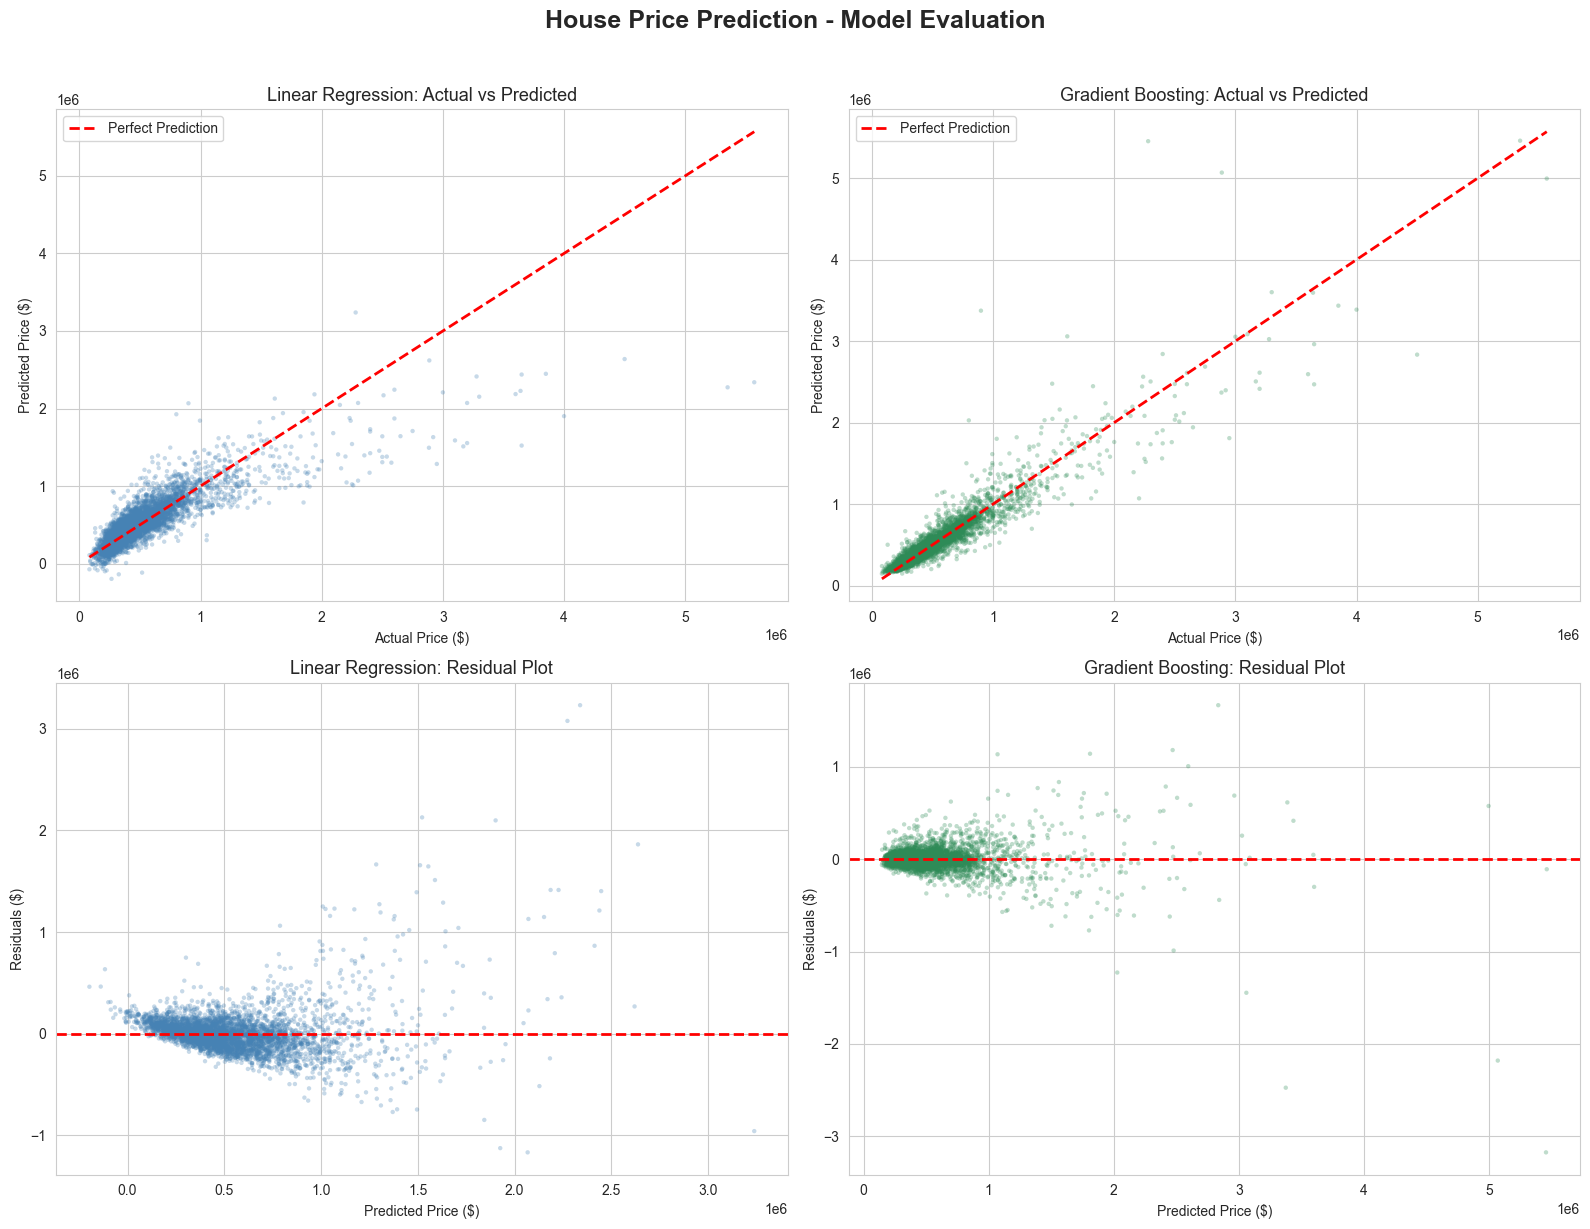

✅ Visualization saved as 'model_comparison.png'


In [8]:
# -----------------------------------------------
# STEP 6: VISUALIZATIONS
# -----------------------------------------------

# Set the overall style for all plots
sns.set_style("whitegrid")

# Create a large figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('House Price Prediction - Model Evaluation', 
             fontsize=18, fontweight='bold', y=1.02)

# -----------------------------------------------
# PLOT 1: Linear Regression - Actual vs Predicted
# A good model should show points close to 
# the red diagonal line (perfect prediction line)
# -----------------------------------------------
axes[0, 0].scatter(y_test, lr_predictions, 
                   alpha=0.3, color='steelblue', edgecolors='none', s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_title('Linear Regression: Actual vs Predicted', fontsize=13)
axes[0, 0].set_xlabel('Actual Price ($)')
axes[0, 0].set_ylabel('Predicted Price ($)')
axes[0, 0].legend()

# -----------------------------------------------
# PLOT 2: Gradient Boosting - Actual vs Predicted
# -----------------------------------------------
axes[0, 1].scatter(y_test, gb_predictions, 
                   alpha=0.3, color='seagreen', edgecolors='none', s=10)
axes[0, 1].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', linewidth=2, label='Perfect Prediction')
axes[0, 1].set_title('Gradient Boosting: Actual vs Predicted', fontsize=13)
axes[0, 1].set_xlabel('Actual Price ($)')
axes[0, 1].set_ylabel('Predicted Price ($)')
axes[0, 1].legend()

# -----------------------------------------------
# PLOT 3: Residual Plot for Linear Regression
# Residuals = Actual - Predicted
# Good model should have residuals centered around 0
# -----------------------------------------------
lr_residuals = y_test - lr_predictions
axes[1, 0].scatter(lr_predictions, lr_residuals, 
                   alpha=0.3, color='steelblue', edgecolors='none', s=10)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_title('Linear Regression: Residual Plot', fontsize=13)
axes[1, 0].set_xlabel('Predicted Price ($)')
axes[1, 0].set_ylabel('Residuals ($)')

# -----------------------------------------------
# PLOT 4: Residual Plot for Gradient Boosting
# -----------------------------------------------
gb_residuals = y_test - gb_predictions
axes[1, 1].scatter(gb_predictions, gb_residuals, 
                   alpha=0.3, color='seagreen', edgecolors='none', s=10)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_title('Gradient Boosting: Residual Plot', fontsize=13)
axes[1, 1].set_xlabel('Predicted Price ($)')
axes[1, 1].set_ylabel('Residuals ($)')

# Adjust spacing between plots
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualization saved as 'model_comparison.png'")

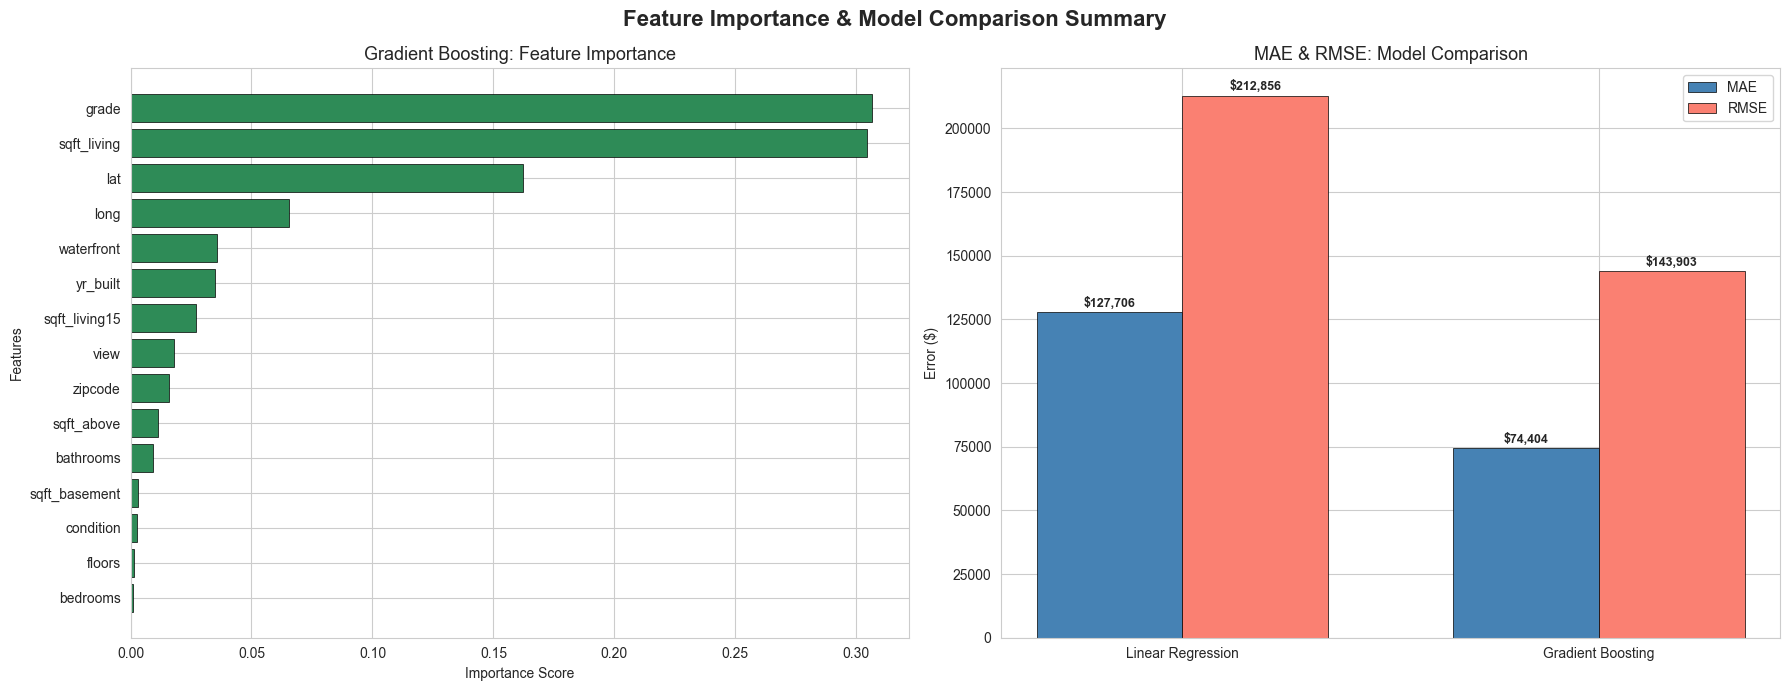

✅ Feature importance & summary plot saved!

           FINAL PROJECT SUMMARY
  Total Samples       : 21613
  Training Samples    : 17290
  Testing Samples     : 4323
  Number of Features  : 15
--------------------------------------------------
  Linear Regression MAE  : $127,706.10
  Linear Regression RMSE : $212,856.42
--------------------------------------------------
  Gradient Boosting MAE  : $74,404.18
  Gradient Boosting RMSE : $143,902.59
✅ Task 6: House Price Prediction COMPLETED!


In [9]:
# -----------------------------------------------
# STEP 7: FEATURE IMPORTANCE & FINAL SUMMARY
# -----------------------------------------------

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Importance & Model Comparison Summary', 
             fontsize=16, fontweight='bold')

# -----------------------------------------------
# PLOT 1: Feature Importance from Gradient Boosting
# Shows which features contribute the most 
# to predicting house prices
# Higher bar = more important feature
# -----------------------------------------------

# Get feature importances from the trained Gradient Boosting model
feature_names = ['sqft_living', 'bedrooms', 'bathrooms', 'floors',
                 'waterfront', 'view', 'condition', 'grade',
                 'sqft_above', 'sqft_basement', 'yr_built',
                 'zipcode', 'lat', 'long', 'sqft_living15']

# Create a DataFrame for easy sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Plot horizontal bar chart
axes[0].barh(importance_df['Feature'], 
             importance_df['Importance'], 
             color='seagreen', edgecolor='black', linewidth=0.5)
axes[0].set_title('Gradient Boosting: Feature Importance', fontsize=13)
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Features')

# -----------------------------------------------
# PLOT 2: MAE & RMSE Comparison Bar Chart
# Side by side comparison of both models
# -----------------------------------------------

# Define model names and their scores
models = ['Linear Regression', 'Gradient Boosting']
mae_scores = [lr_mae, gb_mae]
rmse_scores = [lr_rmse, gb_rmse]

# Set bar positions
x = np.arange(len(models))
width = 0.35

# Plot MAE bars
bars1 = axes[1].bar(x - width/2, mae_scores, width, 
                    label='MAE', color='steelblue', 
                    edgecolor='black', linewidth=0.5)

# Plot RMSE bars
bars2 = axes[1].bar(x + width/2, rmse_scores, width, 
                    label='RMSE', color='salmon', 
                    edgecolor='black', linewidth=0.5)

# Add value labels on top of each bar
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 1000,
                 f'${bar.get_height():,.0f}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 1000,
                 f'${bar.get_height():,.0f}', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_title('MAE & RMSE: Model Comparison', fontsize=13)
axes[1].set_ylabel('Error ($)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()

# Adjust spacing
plt.tight_layout()
plt.savefig('feature_importance_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Feature importance & summary plot saved!")

# -----------------------------------------------
# FINAL SUMMARY PRINTOUT
# -----------------------------------------------
print("\n" + "=" * 50)
print("           FINAL PROJECT SUMMARY")
print("=" * 50)
print(f"  Total Samples       : {len(df)}")
print(f"  Training Samples    : {len(X_train)}")
print(f"  Testing Samples     : {len(X_test)}")
print(f"  Number of Features  : {X.shape[1]}")
print("-" * 50)
print(f"  Linear Regression MAE  : ${lr_mae:,.2f}")
print(f"  Linear Regression RMSE : ${lr_rmse:,.2f}")
print("-" * 50)
print(f"  Gradient Boosting MAE  : ${gb_mae:,.2f}")
print(f"  Gradient Boosting RMSE : ${gb_rmse:,.2f}")
print("=" * 50)
print("✅ Task 6: House Price Prediction COMPLETED!")
print("=" * 50)